In [6]:
import pandas as pd


df = pd.read_csv(r"C:\Users\TechTroniX\Downloads\train.csv\train.csv", encoding="latin-1")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInfo:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region     

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

df = df.drop_duplicates()

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['MonthName'] = df['Order Date'].dt.strftime('%b')

print("Shape after cleaning:", df.shape)
print("\nDate range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("\nMissing values now:")
print(df.isnull().sum())
print("\nData types:")
print(df[['Order Date', 'Ship Date', 'Postal Code', 'Year', 'Month']].dtypes)

Shape after cleaning: (9800, 21)

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00

Missing values now:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
MonthName        0
dtype: int64

Data types:
Order Date     datetime64[ns]
Ship Date      datetime64[ns]
Postal Code             int64
Year                    int32
Month                   int32
dtype: object


In [8]:
print("=== Total Sales ===")
print(f"{df['Sales'].sum():,.0f}")

print("\n=== Sales by Category ===")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

print("\n=== Top 5 Sub-Categories ===")
print(df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5))

print("\n=== Sales by Region ===")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False))

print("\n=== Sales by Year ===")
print(df.groupby('Year')['Sales'].sum())

print("\n=== Top 10 States by Sales ===")
print(df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10))

print("\n=== Sales by Segment ===")
print(df.groupby('Segment')['Sales'].sum().sort_values(ascending=False))

print("\n=== Top 10 Customers ===")
print(df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10))

=== Total Sales ===
2,261,537

=== Sales by Category ===
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

=== Top 5 Sub-Categories ===
Sub-Category
Phones     327782.448
Chairs     322822.731
Storage    219343.392
Tables     202810.628
Binders    200028.785
Name: Sales, dtype: float64

=== Sales by Region ===
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

=== Sales by Year ===
Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

=== Top 10 States by Sales ===
State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float6

In [9]:
df.to_csv("superstore_clean.csv", index=False)

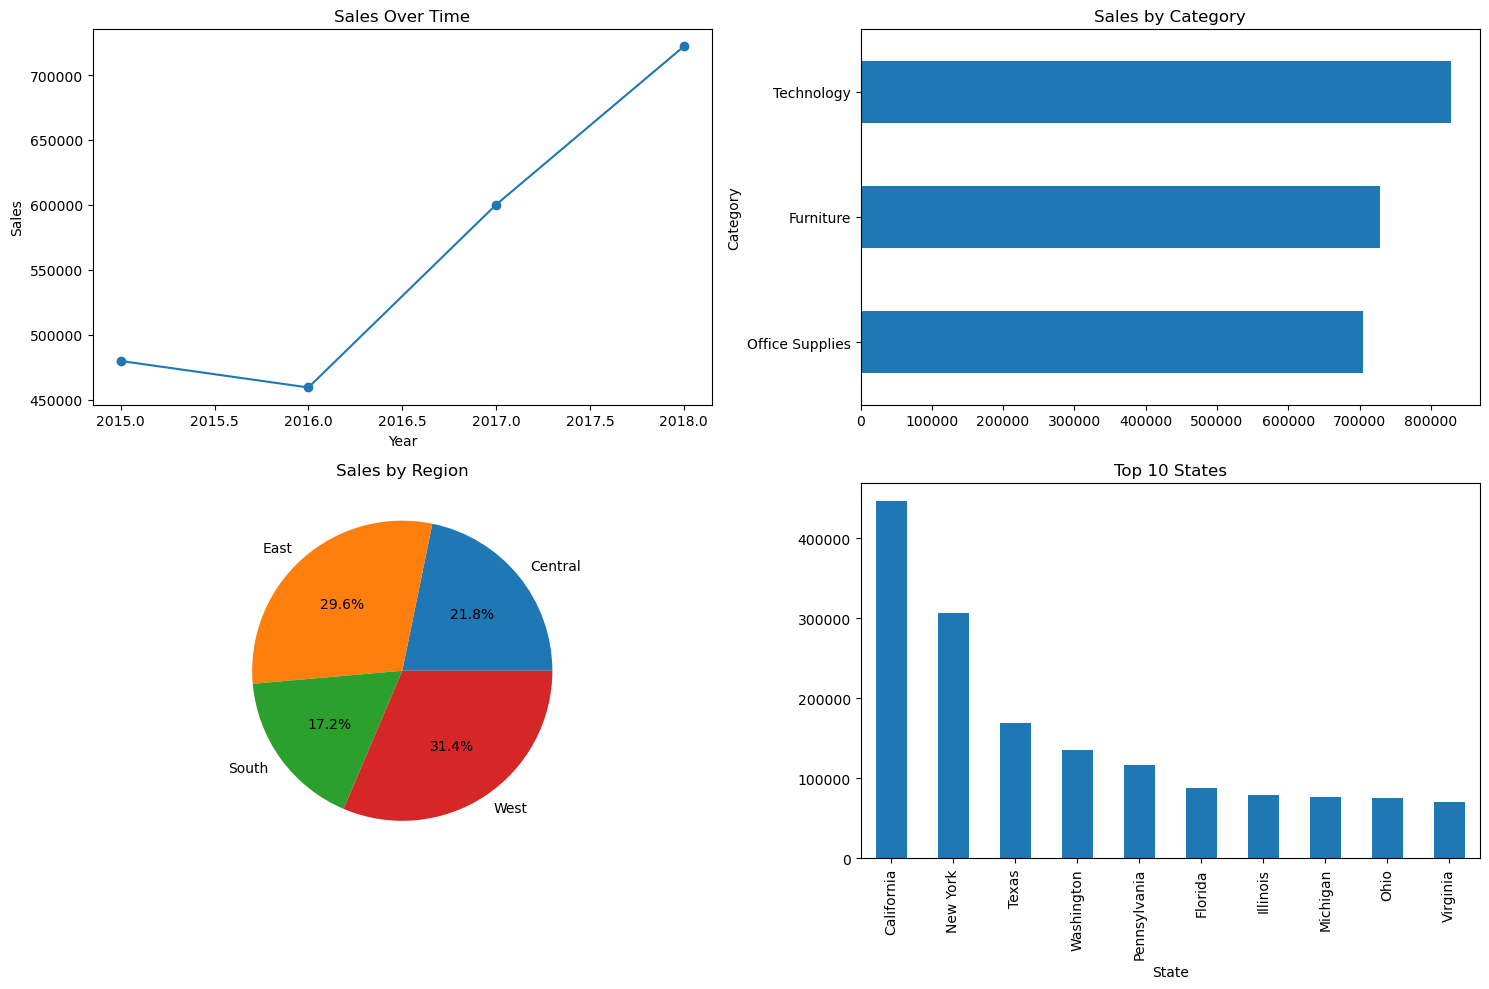

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

df.groupby('Year')['Sales'].sum().plot(kind='line', marker='o', ax=axes[0,0], title='Sales Over Time')
axes[0,0].set_ylabel('Sales')

df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh', ax=axes[0,1], title='Sales by Category')

df.groupby('Region')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,0], title='Sales by Region')
axes[1,0].set_ylabel('')

df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[1,1], title='Top 10 States')

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()